# 🤖 06 — SVM Model Training & Evaluation

**Support Vector Machine (SVM)** implementation for the Tree Carbon ML pipeline.  
This notebook trains and evaluates SVM models on all 4 target formulations:

| # | Target | Type | Model |
|---|--------|------|-------|
| 1 | `TPH.gs.dC.dN0.01` | Regression (raw) | SVR |
| 2 | `target_log` | Regression (log-transformed) | SVR |
| 3 | `target_binary` | Binary Classification | SVC |
| 4 | `target_class3` | Multiclass (3-class) | SVC |

---

## 0. Setup & Imports

In [1]:
# ── Google Colab auto-setup ──────────────────────────────────────────
import os, sys

REPO_DIR = 'Air_Quality_Predictor'

# If running on Colab, clone the repo into a subdirectory and cd into it
if 'google.colab' in sys.modules:
    if not os.path.exists(REPO_DIR):
        !git clone -b SVM https://github.com/shashi2024/Air_Quality_Predictor.git
    os.chdir(REPO_DIR)
    !pip install -r requirements.txt -q

# If running from notebooks/ subdir, move up to repo root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Ensure repo root is in sys.path so 'src' is importable
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

print(f'Working directory: {os.getcwd()}')
print(f'src/ exists: {os.path.exists("src")}')

Working directory: C:\Users\16473\Desktop\SVM
src/ exists: True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
import time

from sklearn.svm import SVR, SVC
from sklearn.model_selection import (
    GridSearchCV, cross_val_score, learning_curve,
    StratifiedKFold, KFold, train_test_split
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.inspection import permutation_importance

# Import our custom SVM module
from src.models.svm_model import (
    SVMRegressor, SVMClassifier, SVMVisualizer,
    save_model, load_model, save_metrics,
    RANDOM_STATE
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)

print('✅ All imports successful!')
print(f'   Random state: {RANDOM_STATE}')

✅ All imports successful!
   Random state: 42


## 1. Load the Model-Ready Dataset

In [3]:
# ── Configuration ───────────────────────────────────────────────────
DATA_DIR     = os.path.join('data', 'processed')
OUTPUT_DIR   = os.path.join('outputs')
FIGURES_DIR  = os.path.join(OUTPUT_DIR, 'figures')
REPORTS_DIR  = os.path.join(OUTPUT_DIR, 'reports')
MODELS_DIR   = os.path.join(OUTPUT_DIR, 'models')

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Load data card ──────────────────────────────────────────────────
card_path = os.path.join(DATA_DIR, 'data_card.json')
with open(card_path) as f:
    data_card = json.load(f)

FEATURE_COLS = data_card['features']
TARGETS      = data_card['targets']

print(f'📊 Dataset: {data_card["dataset_name"]}')
print(f'   Samples : {data_card["n_total"]:,}')
print(f'   Features: {data_card["n_features"]}')
print(f'   Split   : {data_card["split_strategy"]}')
print(f'\n📌 Target columns:')
for k, v in TARGETS.items():
    print(f'   {k:25s} → {v}')
print(f'\n📌 Features ({len(FEATURE_COLS)}):')
for f in FEATURE_COLS:
    print(f'   • {f}')

📊 Dataset: EPA dC/dN Tree Carbon Response to Nitrogen Deposition
   Samples : 110,650
   Features: 19
   Split   : 70/15/15 stratified by NA_L1CODE ecoregion

📌 Target columns:
   regression_raw            → TPH.gs.dC.dN0.01
   regression_log            → target_log
   binary_classification     → target_binary
   multiclass_3              → target_class3

📌 Features (19):
   • EXPN.ha_scaled
   • LAT_scaled
   • LON_scaled
   • eco.EXPN.ha_scaled
   • feat_carbon_sink
   • feat_eco3_target_mean
   • feat_eco_state_ratio
   • feat_enc_NA_L1CODE
   • feat_enc_NA_L3CODE
   • feat_enc_US_L4CODE
   • feat_enc_state
   • feat_expanded_per_ha
   • feat_growth_share
   • feat_gs_ratio
   • feat_lat_bin
   • feat_lat_x_eco1
   • feat_log_magnitude
   • feat_lon_bin
   • state.EXPN.ha_scaled


In [4]:
# ── Load dataset splits ─────────────────────────────────────────────
# Try parquet first, then CSV
loaded = False
for ext, reader in [('.parquet', pd.read_parquet), ('.csv', pd.read_csv)]:
    train_path = os.path.join(DATA_DIR, f'train{ext}')
    val_path   = os.path.join(DATA_DIR, f'val{ext}')
    test_path  = os.path.join(DATA_DIR, f'test{ext}')
    
    if os.path.exists(train_path):
        df_train = reader(train_path)
        df_val   = reader(val_path)
        df_test  = reader(test_path)
        loaded = True
        print(f'✅ Loaded splits from {ext} files')
        break

if not loaded:
    # Try loading single model_ready file
    for ext, reader in [('.parquet', pd.read_parquet), ('.csv', pd.read_csv)]:
        full_path = os.path.join(DATA_DIR, f'model_ready{ext}')
        if os.path.exists(full_path):
            df_full = reader(full_path)
            df_train, df_temp = train_test_split(
                df_full, test_size=0.3, random_state=RANDOM_STATE
            )
            df_val, df_test = train_test_split(
                df_temp, test_size=0.5, random_state=RANDOM_STATE
            )
            loaded = True
            print(f'✅ Loaded & split model_ready{ext}')
            break

if not loaded:
    raise FileNotFoundError(
        '❌ No dataset found! Run notebooks 01-05 first to generate the processed data.'
    )

print(f'\n   Train: {df_train.shape}')
print(f'   Val  : {df_val.shape}')
print(f'   Test : {df_test.shape}')
print(f'\n   Columns: {list(df_train.columns)}')

✅ Loaded splits from .parquet files

   Train: (77455, 25)
   Val  : (16597, 25)
   Test : (16598, 25)

   Columns: ['PLT_CN', 'EXPN.ha_scaled', 'LAT_scaled', 'LON_scaled', 'eco.EXPN.ha_scaled', 'feat_carbon_sink', 'feat_eco3_target_mean', 'feat_eco_state_ratio', 'feat_enc_NA_L1CODE', 'feat_enc_NA_L3CODE', 'feat_enc_US_L4CODE', 'feat_enc_state', 'feat_expanded_per_ha', 'feat_growth_share', 'feat_gs_ratio', 'feat_lat_bin', 'feat_lat_x_eco1', 'feat_log_magnitude', 'feat_lon_bin', 'state.EXPN.ha_scaled', 'TPH.gs.dC.dN0.01', 'target_log', 'target_binary', 'target_class3', 'sample_weight']


In [5]:
# ── Extract features and targets ─────────────────────────────────────
# Filter to features that exist in the dataframe
available_features = [c for c in FEATURE_COLS if c in df_train.columns]
print(f'Using {len(available_features)} / {len(FEATURE_COLS)} features')

X_train = df_train[available_features].values
X_val   = df_val[available_features].values
X_test  = df_test[available_features].values

# Extract all target columns
target_data = {}
for tname, tcol in TARGETS.items():
    if tcol in df_train.columns:
        target_data[tname] = {
            'train': df_train[tcol].values,
            'val':   df_val[tcol].values,
            'test':  df_test[tcol].values,
            'col':   tcol,
        }
        print(f'  ✅ {tname:25s} → {tcol} (unique values: {df_train[tcol].nunique()})')
    else:
        print(f'  ⚠️  {tname:25s} → {tcol} NOT FOUND in dataset')

print(f'\nX_train shape: {X_train.shape}')
print(f'X_val shape  : {X_val.shape}')
print(f'X_test shape : {X_test.shape}')

Using 19 / 19 features
  ✅ regression_raw            → TPH.gs.dC.dN0.01 (unique values: 71774)
  ✅ regression_log            → target_log (unique values: 71774)
  ✅ binary_classification     → target_binary (unique values: 2)
  ✅ multiclass_3              → target_class3 (unique values: 3)

X_train shape: (77455, 19)
X_val shape  : (16597, 19)
X_test shape : (16598, 19)


---

## 2. SVM for Regression — Raw Target (`TPH.gs.dC.dN0.01`)

Support Vector Regression (SVR) with RBF kernel on the raw dC/dN values.

In [6]:
# ── 2.1 Train SVR on raw regression target ──────────────────────────
print('='*60)
print('  SVR — Regression (Raw Target)')
print('='*60)

tkey = 'regression_raw'
if tkey in target_data:
    y_train_raw = target_data[tkey]['train']
    y_val_raw   = target_data[tkey]['val']
    y_test_raw  = target_data[tkey]['test']
    
    # Subsample for SVM (large datasets are slow with SVM)
    n_subsample = min(10000, len(X_train))
    idx = np.random.RandomState(RANDOM_STATE).choice(
        len(X_train), n_subsample, replace=False
    )
    X_train_sub = X_train[idx]
    y_train_sub = y_train_raw[idx]
    print(f'\n📏 Subsampled {n_subsample:,} / {len(X_train):,} training samples for SVR')
    
    # Initialize and tune
    svr_raw = SVMRegressor()
    start_time = time.time()
    svr_raw.tune_hyperparameters(
        X_train_sub, y_train_sub,
        cv=5, scoring='neg_mean_squared_error', fast=True
    )
    elapsed = time.time() - start_time
    print(f'\n⏱️  Tuning time: {elapsed:.1f}s')
else:
    print(f'⚠️  Target "{tkey}" not available')

  SVR — Regression (Raw Target)

📏 Subsampled 10,000 / 77,455 training samples for SVR
Fitting 5 folds for each of 12 candidates, totalling 60 fits



✅ Best SVR Parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
   Best CV Score (neg MSE): -52.5587

⏱️  Tuning time: 269.1s


In [7]:
# ── 2.2 Evaluate SVR (raw) ───────────────────────────────────────────
if tkey in target_data:
    # Validation set
    metrics_val_raw, y_pred_val_raw = svr_raw.evaluate(
        X_val, y_val_raw, dataset_name='Validation'
    )
    
    # Test set
    metrics_test_raw, y_pred_test_raw = svr_raw.evaluate(
        X_test, y_test_raw, dataset_name='Test'
    )
    
    # Cross-validation
    cv_scores_raw = svr_raw.cross_validate(X_train_sub, y_train_sub, cv=5)


📊 SVR Evaluation (Validation):
   MAE  = 1.2537
   RMSE = 6.2891
   R²   = 0.9713
   MAPE = 34059469163613.4570



📊 SVR Evaluation (Test):
   MAE  = 1.2186
   RMSE = 6.2519
   R²   = 0.9711
   MAPE = 38218838125775.8984



📊 SVR Cross-Validation (k=5):
   MSE  = 51.8884 ± 13.9111
   MAE  = 1.4624 ± 0.0718
   R²   = 0.9629 ± 0.0107


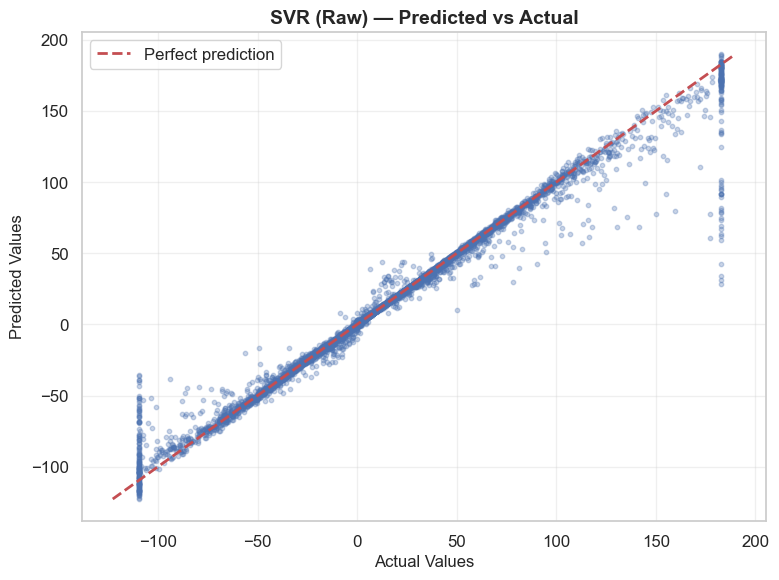

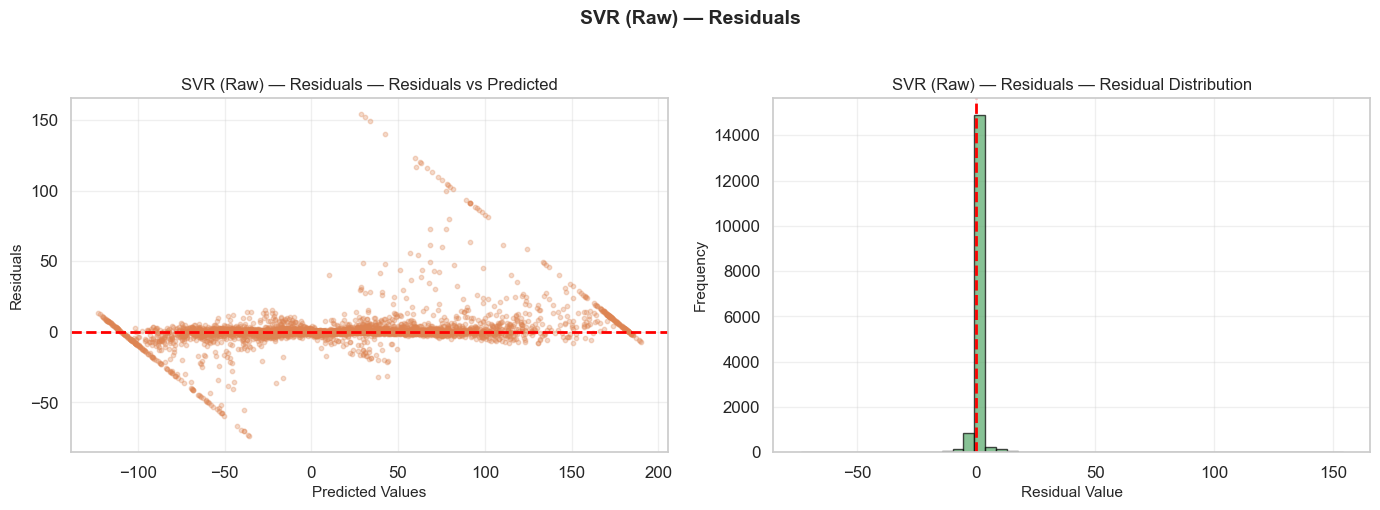

In [8]:
# ── 2.3 Visualize SVR (raw) results ──────────────────────────────────
if tkey in target_data:
    viz = SVMVisualizer()
    
    # Predicted vs Actual
    viz.plot_predicted_vs_actual(
        y_test_raw, y_pred_test_raw,
        title='SVR (Raw) — Predicted vs Actual',
        save_path=os.path.join(FIGURES_DIR, 'svr_raw_pred_vs_actual.png')
    )
    
    # Residuals
    viz.plot_residuals(
        y_test_raw, y_pred_test_raw,
        title='SVR (Raw) — Residuals',
        save_path=os.path.join(FIGURES_DIR, 'svr_raw_residuals.png')
    )

---

## 3. SVM for Regression — Log-Transformed Target (`target_log`)

SVR on the signed log1p transformation of the dC/dN values.

In [9]:
# ── 3.1 Train SVR on log-transformed target ──────────────────────────
print('='*60)
print('  SVR — Regression (Log-Transformed Target)')
print('='*60)

tkey_log = 'regression_log'
if tkey_log in target_data:
    y_train_log = target_data[tkey_log]['train']
    y_val_log   = target_data[tkey_log]['val']
    y_test_log  = target_data[tkey_log]['test']
    
    # Use same subsample indices
    y_train_sub_log = y_train_log[idx]
    
    svr_log = SVMRegressor()
    start_time = time.time()
    svr_log.tune_hyperparameters(
        X_train_sub, y_train_sub_log,
        cv=5, scoring='neg_mean_squared_error', fast=True
    )
    elapsed = time.time() - start_time
    print(f'\n⏱️  Tuning time: {elapsed:.1f}s')
else:
    print(f'⚠️  Target "{tkey_log}" not available')

  SVR — Regression (Log-Transformed Target)
Fitting 5 folds for each of 12 candidates, totalling 60 fits



✅ Best SVR Parameters: {'C': 1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
   Best CV Score (neg MSE): -0.0024

⏱️  Tuning time: 64.1s


In [10]:
# ── 3.2 Evaluate SVR (log) ───────────────────────────────────────────
if tkey_log in target_data:
    metrics_val_log, y_pred_val_log = svr_log.evaluate(
        X_val, y_val_log, dataset_name='Validation'
    )
    
    metrics_test_log, y_pred_test_log = svr_log.evaluate(
        X_test, y_test_log, dataset_name='Test'
    )
    
    cv_scores_log = svr_log.cross_validate(X_train_sub, y_train_sub_log, cv=5)


📊 SVR Evaluation (Validation):
   MAE  = 0.0414
   RMSE = 0.0497
   R²   = 0.9996
   MAPE = 24890939571336.7227

📊 SVR Evaluation (Test):
   MAE  = 0.0413
   RMSE = 0.0495
   R²   = 0.9996
   MAPE = 24730405341947.2188



📊 SVR Cross-Validation (k=5):
   MSE  = 0.0024 ± 0.0000
   MAE  = 0.0414 ± 0.0003
   R²   = 0.9997 ± 0.0000


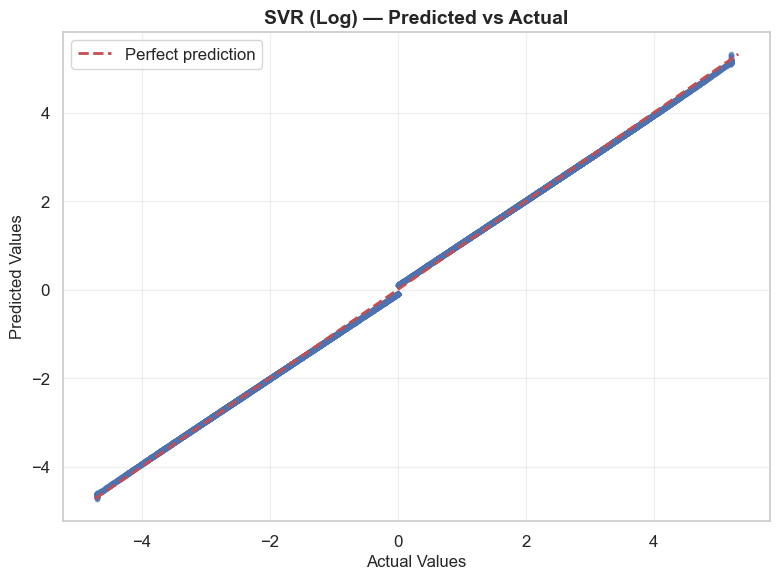

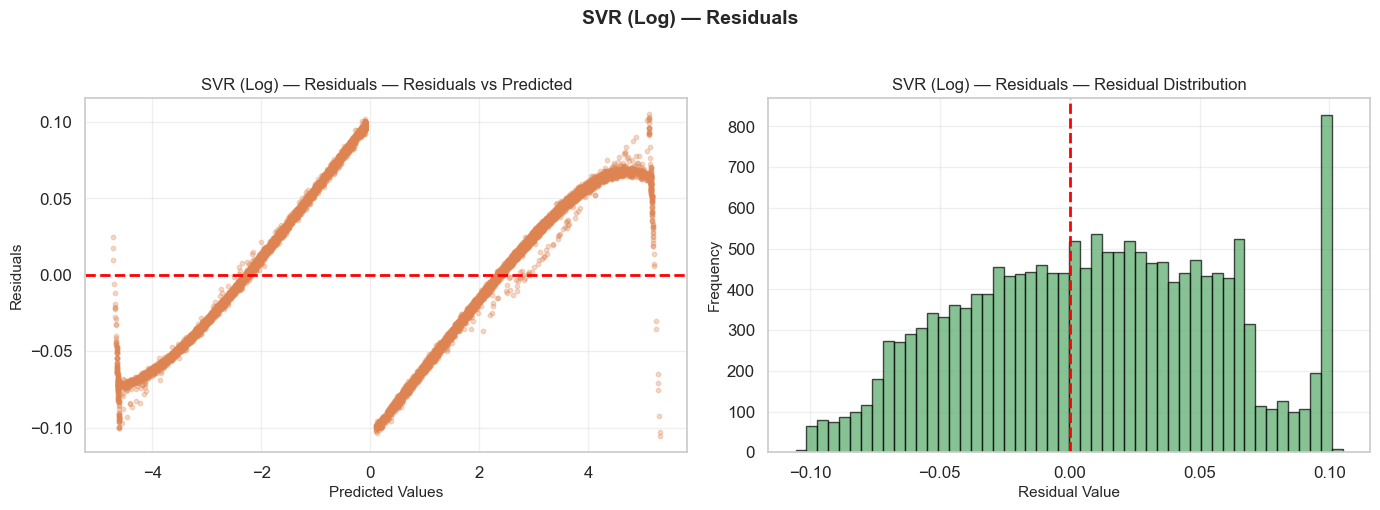

In [11]:
# ── 3.3 Visualize SVR (log) results ──────────────────────────────────
if tkey_log in target_data:
    viz.plot_predicted_vs_actual(
        y_test_log, y_pred_test_log,
        title='SVR (Log) — Predicted vs Actual',
        save_path=os.path.join(FIGURES_DIR, 'svr_log_pred_vs_actual.png')
    )
    
    viz.plot_residuals(
        y_test_log, y_pred_test_log,
        title='SVR (Log) — Residuals',
        save_path=os.path.join(FIGURES_DIR, 'svr_log_residuals.png')
    )

---

## 4. SVM for Binary Classification (`target_binary`)

SVC predicting whether a plot is a **carbon sink** (positive dC/dN) or **carbon source** (negative).

In [12]:
# ── 4.1 Train SVC on binary target ───────────────────────────────────
print('='*60)
print('  SVC — Binary Classification')
print('='*60)

tkey_bin = 'binary_classification'
if tkey_bin in target_data:
    y_train_bin = target_data[tkey_bin]['train']
    y_val_bin   = target_data[tkey_bin]['val']
    y_test_bin  = target_data[tkey_bin]['test']
    
    y_train_sub_bin = y_train_bin[idx]
    
    print(f'Class distribution (train subsample):')
    unique, counts = np.unique(y_train_sub_bin, return_counts=True)
    for u, c in zip(unique, counts):
        print(f'  Class {u}: {c} ({c/len(y_train_sub_bin)*100:.1f}%)')
    
    svc_binary = SVMClassifier()
    start_time = time.time()
    svc_binary.tune_hyperparameters(
        X_train_sub, y_train_sub_bin,
        cv=5, scoring='f1_weighted', fast=True
    )
    elapsed = time.time() - start_time
    print(f'\n⏱️  Tuning time: {elapsed:.1f}s')
else:
    print(f'⚠️  Target "{tkey_bin}" not available')

  SVC — Binary Classification
Class distribution (train subsample):
  Class 0: 4487 (44.9%)
  Class 1: 5513 (55.1%)
Fitting 5 folds for each of 12 candidates, totalling 60 fits



✅ Best SVC Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
   Best CV Score (f1_weighted): 1.0000

⏱️  Tuning time: 10.2s


In [13]:
# ── 4.2 Evaluate SVC (binary) ────────────────────────────────────────
if tkey_bin in target_data:
    metrics_val_bin, y_pred_val_bin = svc_binary.evaluate(
        X_val, y_val_bin, dataset_name='Validation'
    )
    
    metrics_test_bin, y_pred_test_bin = svc_binary.evaluate(
        X_test, y_test_bin, dataset_name='Test'
    )
    
    # Classification report
    print('\n📋 Classification Report (Test Set):')
    print(classification_report(
        y_test_bin, y_pred_test_bin,
        target_names=['Carbon Source (0)', 'Carbon Sink (1)']
    ))
    
    # Cross-validation
    cv_scores_bin = svc_binary.cross_validate(X_train_sub, y_train_sub_bin, cv=5)


📊 SVC Evaluation (Validation):
   Accuracy  = 1.0000
   Precision = 1.0000
   Recall    = 1.0000
   F1 Score  = 1.0000
   ROC-AUC   = 1.0000



📊 SVC Evaluation (Test):
   Accuracy  = 1.0000
   Precision = 1.0000
   Recall    = 1.0000
   F1 Score  = 1.0000
   ROC-AUC   = 1.0000

📋 Classification Report (Test Set):
                   precision    recall  f1-score   support

Carbon Source (0)       1.00      1.00      1.00      7512
  Carbon Sink (1)       1.00      1.00      1.00      9086

         accuracy                           1.00     16598
        macro avg       1.00      1.00      1.00     16598
     weighted avg       1.00      1.00      1.00     16598




📊 SVC Cross-Validation (k=5):
   Accuracy  = 1.0000 ± 0.0000
   F1 (w)    = 1.0000 ± 0.0000
   Prec (w)  = 1.0000 ± 0.0000
   Recall(w) = 1.0000 ± 0.0000


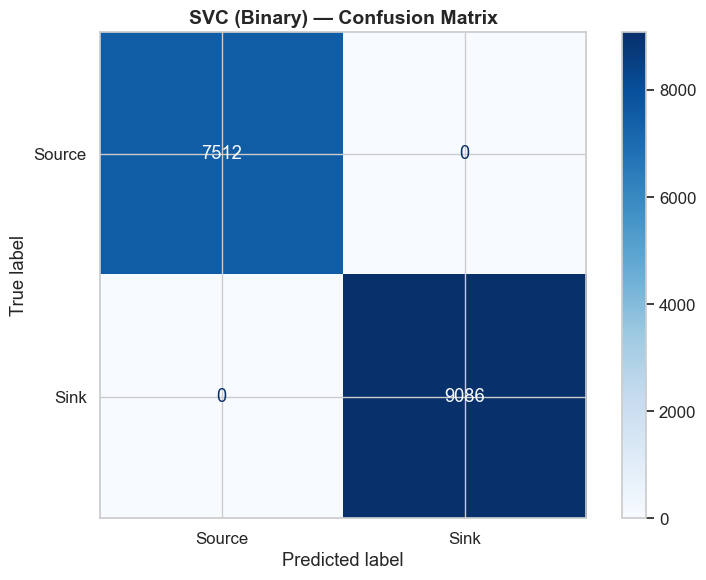

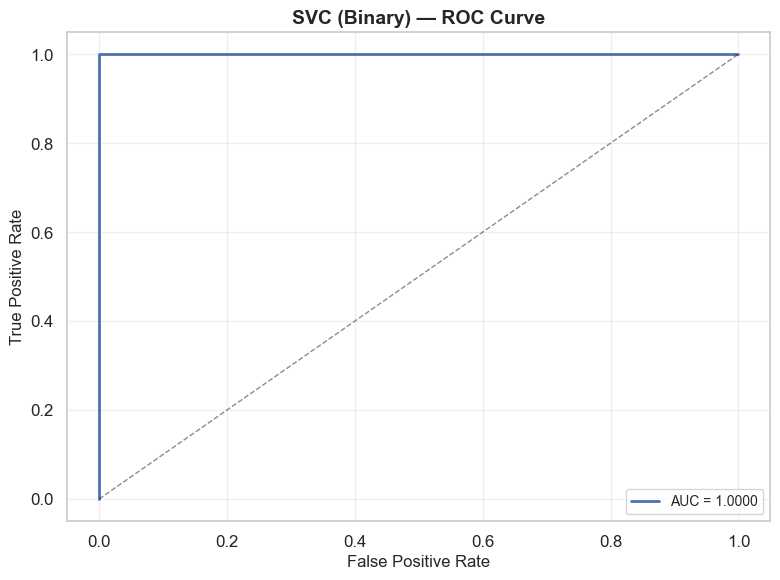

In [14]:
# ── 4.3 Visualize SVC (binary) results ───────────────────────────────
if tkey_bin in target_data:
    # Confusion Matrix
    viz.plot_confusion_matrix(
        y_test_bin, y_pred_test_bin,
        class_names=['Source', 'Sink'],
        title='SVC (Binary) — Confusion Matrix',
        save_path=os.path.join(FIGURES_DIR, 'svc_binary_confusion_matrix.png')
    )
    
    # ROC Curve
    y_proba_bin = svc_binary.predict_proba(X_test)
    viz.plot_roc_curve(
        y_test_bin, y_proba_bin,
        class_names=['Source', 'Sink'],
        title='SVC (Binary) — ROC Curve',
        save_path=os.path.join(FIGURES_DIR, 'svc_binary_roc_curve.png')
    )

---

## 5. SVM for Multiclass Classification (`target_class3`)

SVC predicting 3 classes of carbon response intensity.

In [15]:
# ── 5.1 Train SVC on multiclass target ───────────────────────────────
print('='*60)
print('  SVC — Multiclass Classification (3 classes)')
print('='*60)

tkey_mc = 'multiclass_3'
if tkey_mc in target_data:
    y_train_mc = target_data[tkey_mc]['train']
    y_val_mc   = target_data[tkey_mc]['val']
    y_test_mc  = target_data[tkey_mc]['test']
    
    y_train_sub_mc = y_train_mc[idx]
    
    print(f'Class distribution (train subsample):')
    unique, counts = np.unique(y_train_sub_mc, return_counts=True)
    for u, c in zip(unique, counts):
        print(f'  Class {u}: {c} ({c/len(y_train_sub_mc)*100:.1f}%)')
    
    svc_multi = SVMClassifier()
    start_time = time.time()
    svc_multi.tune_hyperparameters(
        X_train_sub, y_train_sub_mc,
        cv=5, scoring='f1_weighted', fast=True
    )
    elapsed = time.time() - start_time
    print(f'\n⏱️  Tuning time: {elapsed:.1f}s')
else:
    print(f'⚠️  Target "{tkey_mc}" not available')

  SVC — Multiclass Classification (3 classes)
Class distribution (train subsample):
  Class 0: 3318 (33.2%)
  Class 1: 3288 (32.9%)
  Class 2: 3394 (33.9%)
Fitting 5 folds for each of 12 candidates, totalling 60 fits



✅ Best SVC Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
   Best CV Score (f1_weighted): 0.9942

⏱️  Tuning time: 36.1s


In [16]:
# ── 5.2 Evaluate SVC (multiclass) ────────────────────────────────────
if tkey_mc in target_data:
    metrics_val_mc, y_pred_val_mc = svc_multi.evaluate(
        X_val, y_val_mc, dataset_name='Validation'
    )
    
    metrics_test_mc, y_pred_test_mc = svc_multi.evaluate(
        X_test, y_test_mc, dataset_name='Test'
    )
    
    # Classification report
    class_names_3 = ['Low Response', 'Medium Response', 'High Response']
    print('\n📋 Classification Report (Test Set):')
    print(classification_report(
        y_test_mc, y_pred_test_mc,
        target_names=class_names_3[:len(np.unique(y_test_mc))]
    ))
    
    cv_scores_mc = svc_multi.cross_validate(X_train_sub, y_train_sub_mc, cv=5)


📊 SVC Evaluation (Validation):
   Accuracy  = 0.9952
   Precision = 0.9952
   Recall    = 0.9952
   F1 Score  = 0.9952
   ROC-AUC   = 1.0000



📊 SVC Evaluation (Test):
   Accuracy  = 0.9952
   Precision = 0.9952
   Recall    = 0.9952
   F1 Score  = 0.9952
   ROC-AUC   = 0.9999

📋 Classification Report (Test Set):
                 precision    recall  f1-score   support

   Low Response       1.00      1.00      1.00      5462
Medium Response       0.99      0.99      0.99      5462
  High Response       0.99      1.00      0.99      5674

       accuracy                           1.00     16598
      macro avg       1.00      1.00      1.00     16598
   weighted avg       1.00      1.00      1.00     16598




📊 SVC Cross-Validation (k=5):
   Accuracy  = 0.9942 ± 0.0025
   F1 (w)    = 0.9942 ± 0.0025
   Prec (w)  = 0.9942 ± 0.0025
   Recall(w) = 0.9942 ± 0.0025


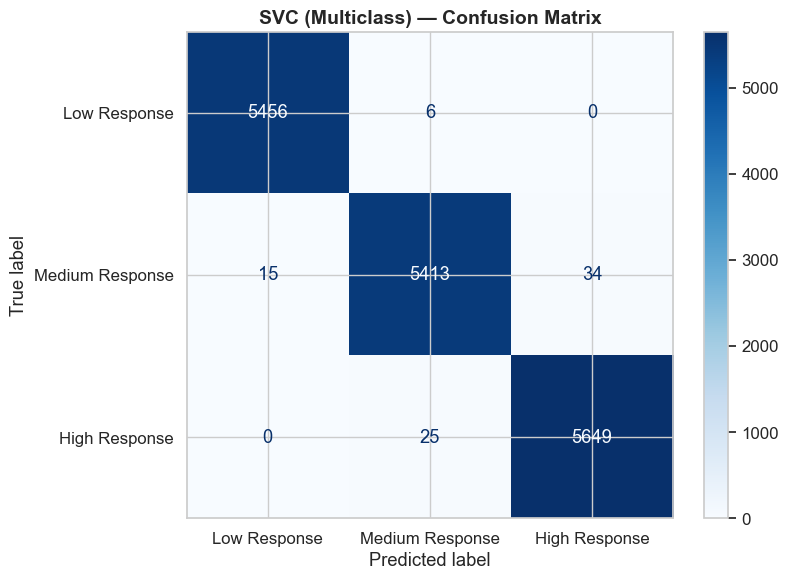

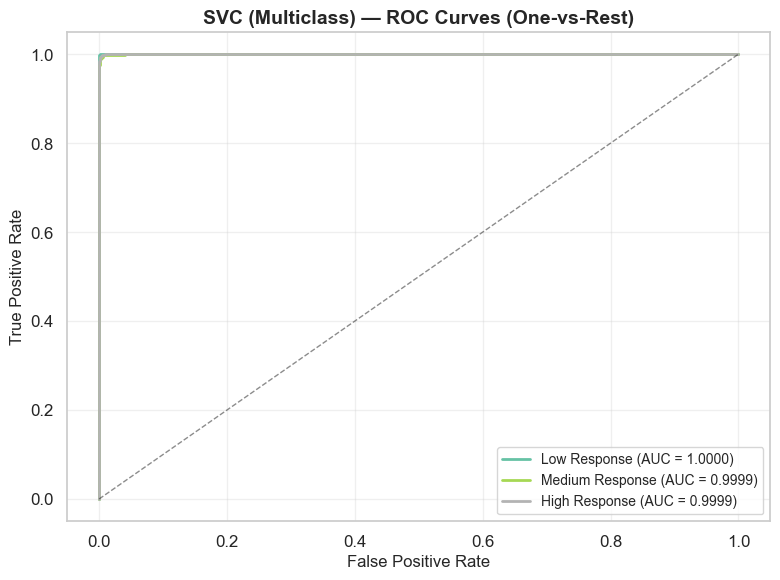

In [17]:
# ── 5.3 Visualize SVC (multiclass) results ───────────────────────────
if tkey_mc in target_data:
    # Confusion Matrix
    viz.plot_confusion_matrix(
        y_test_mc, y_pred_test_mc,
        class_names=class_names_3[:len(np.unique(y_test_mc))],
        title='SVC (Multiclass) — Confusion Matrix',
        save_path=os.path.join(FIGURES_DIR, 'svc_multi_confusion_matrix.png')
    )
    
    # ROC Curve (OVR)
    y_proba_mc = svc_multi.predict_proba(X_test)
    viz.plot_roc_curve(
        y_test_mc, y_proba_mc,
        class_names=class_names_3[:len(np.unique(y_test_mc))],
        title='SVC (Multiclass) — ROC Curves (One-vs-Rest)',
        save_path=os.path.join(FIGURES_DIR, 'svc_multi_roc_curves.png')
    )

---

## 6. Feature Importance Analysis

  Feature Importance — Permutation-based


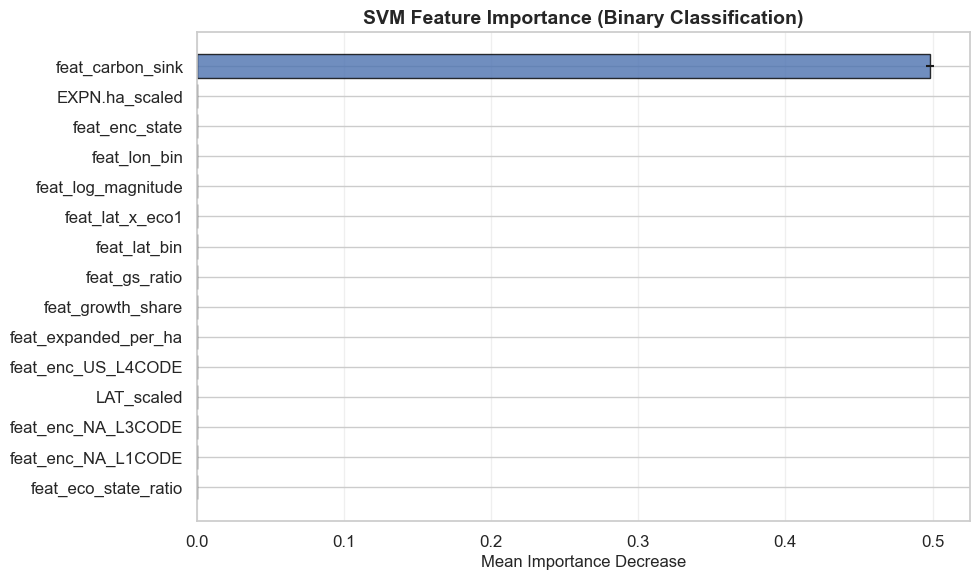


Top features by importance:
             Feature  Importance     Std
    feat_carbon_sink    0.497964 0.00273
      EXPN.ha_scaled    0.000000 0.00000
      feat_enc_state    0.000000 0.00000
        feat_lon_bin    0.000000 0.00000
  feat_log_magnitude    0.000000 0.00000
     feat_lat_x_eco1    0.000000 0.00000
        feat_lat_bin    0.000000 0.00000
       feat_gs_ratio    0.000000 0.00000
   feat_growth_share    0.000000 0.00000
feat_expanded_per_ha    0.000000 0.00000
  feat_enc_US_L4CODE    0.000000 0.00000
          LAT_scaled    0.000000 0.00000
  feat_enc_NA_L3CODE    0.000000 0.00000
  feat_enc_NA_L1CODE    0.000000 0.00000
feat_eco_state_ratio    0.000000 0.00000


In [18]:
# ── 6.1 Permutation Importance (best model) ──────────────────────────
print('='*60)
print('  Feature Importance — Permutation-based')
print('='*60)

# Use the binary SVC model for feature importance (most interpretable)
if 'svc_binary' in dir() and svc_binary.is_fitted:
    model_for_fi = svc_binary.best_model if svc_binary.best_model else svc_binary.model
    X_test_scaled = svc_binary.scaler.transform(X_test)
    
    fig, importance_df = viz.plot_feature_importance(
        model_for_fi, X_test_scaled, y_test_bin,
        feature_names=available_features,
        title='SVM Feature Importance (Binary Classification)',
        top_n=min(15, len(available_features)),
        save_path=os.path.join(FIGURES_DIR, 'svm_feature_importance.png')
    )
    print('\nTop features by importance:')
    print(importance_df.to_string(index=False))

elif 'svr_raw' in dir() and svr_raw.is_fitted:
    model_for_fi = svr_raw.best_model if svr_raw.best_model else svr_raw.model
    X_test_scaled = svr_raw.scaler.transform(X_test)
    
    fig, importance_df = viz.plot_feature_importance(
        model_for_fi, X_test_scaled, y_test_raw,
        feature_names=available_features,
        title='SVM Feature Importance (Raw Regression)',
        top_n=min(15, len(available_features)),
        save_path=os.path.join(FIGURES_DIR, 'svm_feature_importance.png')
    )
    print('\nTop features by importance:')
    print(importance_df.to_string(index=False))

---

## 7. Learning Curves

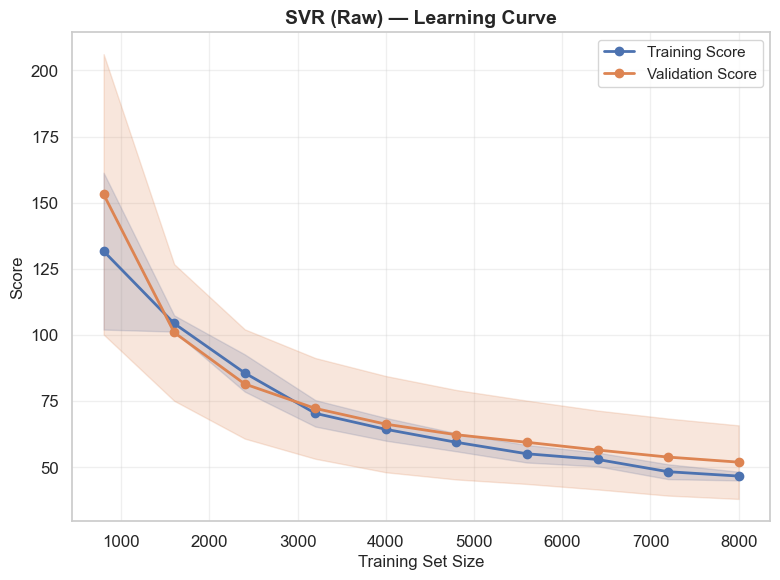

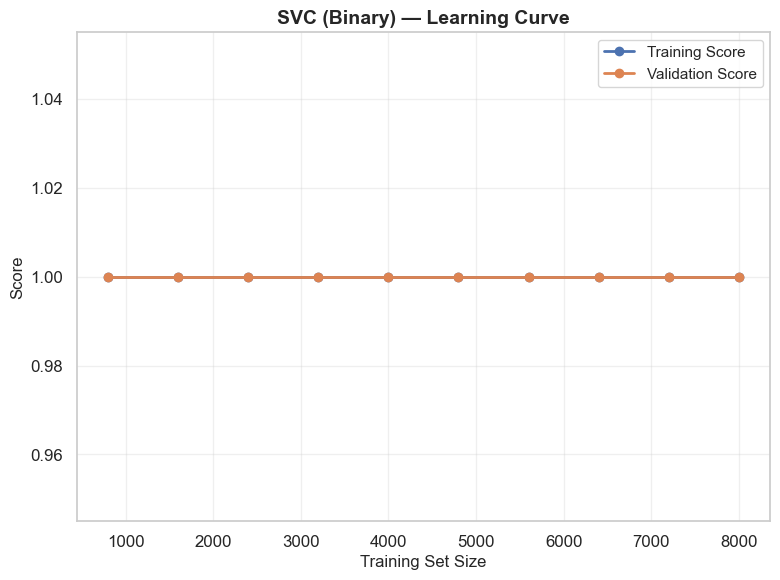

In [19]:
# ── 7.1 Learning Curve for SVR (raw) ─────────────────────────────────
if 'svr_raw' in dir() and svr_raw.is_fitted:
    model_lc = svr_raw.best_model if svr_raw.best_model else svr_raw.model
    X_sub_scaled = svr_raw.scaler.transform(X_train_sub)
    
    viz.plot_learning_curve(
        model_lc, X_sub_scaled, y_train_sub,
        cv=5, scoring='neg_mean_squared_error',
        title='SVR (Raw) — Learning Curve',
        save_path=os.path.join(FIGURES_DIR, 'svr_raw_learning_curve.png')
    )

# ── 7.2 Learning Curve for SVC (binary) ──────────────────────────────
if 'svc_binary' in dir() and svc_binary.is_fitted:
    model_lc_c = svc_binary.best_model if svc_binary.best_model else svc_binary.model
    X_sub_scaled_c = svc_binary.scaler.transform(X_train_sub)
    
    viz.plot_learning_curve(
        model_lc_c, X_sub_scaled_c, y_train_sub_bin,
        cv=5, scoring='accuracy',
        title='SVC (Binary) — Learning Curve',
        save_path=os.path.join(FIGURES_DIR, 'svc_binary_learning_curve.png')
    )

---

## 8. Comparison Summary — All 4 Targets

In [20]:
# ── 8.1 Compile all metrics ──────────────────────────────────────────
print('='*60)
print('  📊 SVM Results Summary — All Targets')
print('='*60)

all_results = {}

# Regression results
if 'metrics_test_raw' in dir():
    all_results['SVR_Raw'] = metrics_test_raw
    print(f'\n🔹 SVR (Raw Regression):')
    for k, v in metrics_test_raw.items():
        print(f'   {k:6s} = {v:.4f}')

if 'metrics_test_log' in dir():
    all_results['SVR_Log'] = metrics_test_log
    print(f'\n🔹 SVR (Log Regression):')
    for k, v in metrics_test_log.items():
        print(f'   {k:6s} = {v:.4f}')

# Classification results
if 'metrics_test_bin' in dir():
    all_results['SVC_Binary'] = metrics_test_bin
    print(f'\n🔹 SVC (Binary Classification):')
    for k, v in metrics_test_bin.items():
        if v is not None:
            print(f'   {k:10s} = {v:.4f}')

if 'metrics_test_mc' in dir():
    all_results['SVC_Multi3'] = metrics_test_mc
    print(f'\n🔹 SVC (3-class Classification):')
    for k, v in metrics_test_mc.items():
        if v is not None:
            print(f'   {k:10s} = {v:.4f}')

  📊 SVM Results Summary — All Targets

🔹 SVR (Raw Regression):
   MAE    = 1.2186
   RMSE   = 6.2519
   R2     = 0.9711
   MAPE   = 38218838125775.8984

🔹 SVR (Log Regression):
   MAE    = 0.0413
   RMSE   = 0.0495
   R2     = 0.9996
   MAPE   = 24730405341947.2188

🔹 SVC (Binary Classification):
   Accuracy   = 1.0000
   Precision  = 1.0000
   Recall     = 1.0000
   F1_Score   = 1.0000
   ROC_AUC    = 1.0000

🔹 SVC (3-class Classification):
   Accuracy   = 0.9952
   Precision  = 0.9952
   Recall     = 0.9952
   F1_Score   = 0.9952
   ROC_AUC    = 0.9999


In [21]:
# ── 8.2 Summary table ────────────────────────────────────────────────
if all_results:
    summary_df = pd.DataFrame(all_results).T
    summary_df.index.name = 'Model'
    print('\n📋 Full Results Table:')
    display(summary_df.round(4))
    
    # Save to CSV
    summary_path = os.path.join(REPORTS_DIR, 'svm_results_summary.csv')
    summary_df.to_csv(summary_path)
    print(f'\n💾 Saved to: {summary_path}')


📋 Full Results Table:


,MAE,RMSE,R2,MAPE,Accuracy,Precision,Recall,F1_Score,ROC_AUC
Model,,,,,,,,,
SVR_Raw,1.2186,6.2519,0.9711,3.821884e+13,NaN,NaN,NaN,NaN,NaN
SVR_Log,0.0413,0.0495,0.9996,2.473041e+13,NaN,NaN,NaN,NaN,NaN
SVC_Binary,NaN,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,1.0000
SVC_Multi3,NaN,NaN,NaN,NaN,0.9952,0.9952,0.9952,0.9952,0.9999



💾 Saved to: outputs\reports\svm_results_summary.csv


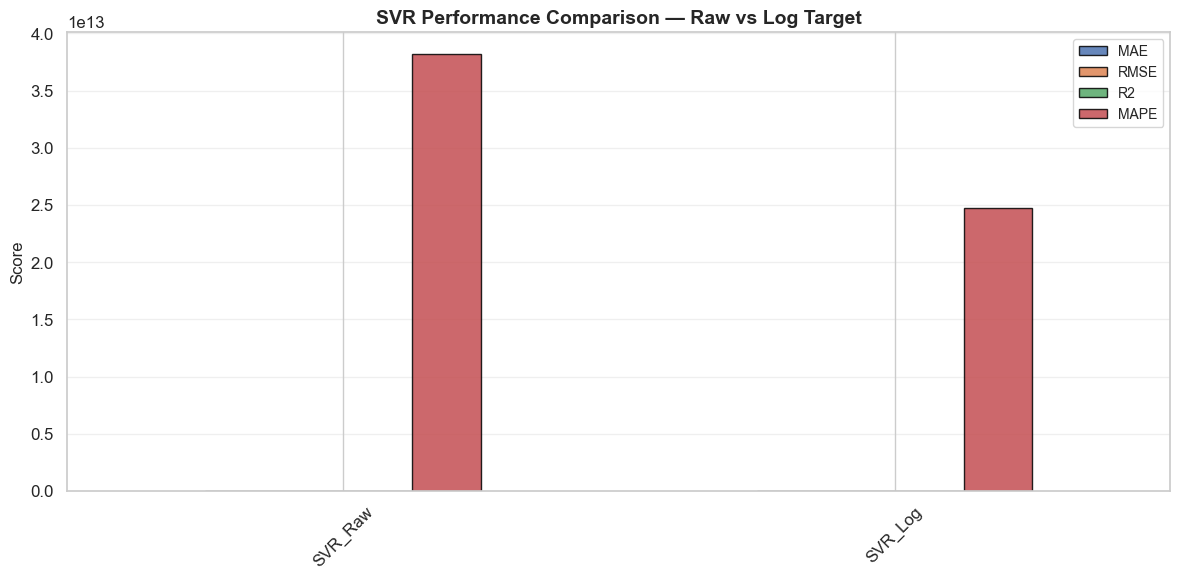

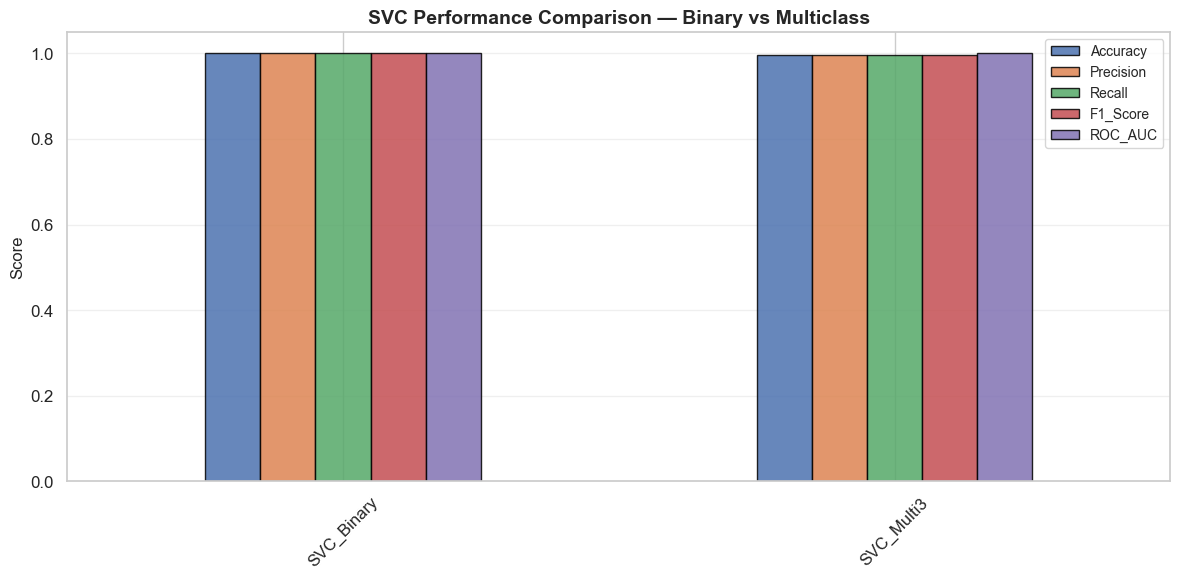

In [22]:
# ── 8.3 Regression comparison chart ──────────────────────────────────
reg_results = {k: v for k, v in all_results.items() if 'SVR' in k}
if reg_results:
    viz.plot_metrics_comparison(
        reg_results,
        title='SVR Performance Comparison — Raw vs Log Target',
        save_path=os.path.join(FIGURES_DIR, 'svr_comparison.png')
    )

# ── 8.4 Classification comparison chart ──────────────────────────────
cls_results = {k: v for k, v in all_results.items() if 'SVC' in k}
if cls_results:
    # Remove None values for plotting
    cls_clean = {}
    for model_name, metrics in cls_results.items():
        cls_clean[model_name] = {k: v for k, v in metrics.items() if v is not None}
    viz.plot_metrics_comparison(
        cls_clean,
        title='SVC Performance Comparison — Binary vs Multiclass',
        save_path=os.path.join(FIGURES_DIR, 'svc_comparison.png')
    )

---

## 9. Save Models & Reports

In [23]:
# ── 9.1 Save trained models ──────────────────────────────────────────
print('='*60)
print('  💾 Saving Models & Reports')
print('='*60)

if 'svr_raw' in dir() and svr_raw.is_fitted:
    save_model(svr_raw, os.path.join(MODELS_DIR, 'svr_raw_model.pkl'))

if 'svr_log' in dir() and svr_log.is_fitted:
    save_model(svr_log, os.path.join(MODELS_DIR, 'svr_log_model.pkl'))

if 'svc_binary' in dir() and svc_binary.is_fitted:
    save_model(svc_binary, os.path.join(MODELS_DIR, 'svc_binary_model.pkl'))

if 'svc_multi' in dir() and svc_multi.is_fitted:
    save_model(svc_multi, os.path.join(MODELS_DIR, 'svc_multi_model.pkl'))

  💾 Saving Models & Reports
💾 Model saved to: outputs\models\svr_raw_model.pkl
💾 Model saved to: outputs\models\svr_log_model.pkl
💾 Model saved to: outputs\models\svc_binary_model.pkl
💾 Model saved to: outputs\models\svc_multi_model.pkl


In [24]:
# ── 9.2 Save all metrics as JSON ─────────────────────────────────────
full_report = {
    'model_type': 'SVM (Support Vector Machine)',
    'library': 'scikit-learn',
    'random_state': RANDOM_STATE,
    'subsample_size': n_subsample if 'n_subsample' in dir() else 'N/A',
    'feature_count': len(available_features),
    'features_used': available_features,
}

# Add best params
if 'svr_raw' in dir() and svr_raw.best_params:
    full_report['svr_raw_best_params'] = svr_raw.best_params
if 'svr_log' in dir() and svr_log.best_params:
    full_report['svr_log_best_params'] = svr_log.best_params
if 'svc_binary' in dir() and svc_binary.best_params:
    full_report['svc_binary_best_params'] = svc_binary.best_params
if 'svc_multi' in dir() and svc_multi.best_params:
    full_report['svc_multi_best_params'] = svc_multi.best_params

# Add metrics
full_report['results'] = all_results

save_metrics(full_report, os.path.join(REPORTS_DIR, 'svm_full_report.json'))

print('\n✅ All models and reports saved successfully!')

📝 Metrics saved to: outputs\reports\svm_full_report.json

✅ All models and reports saved successfully!


---

## 10. Hyperparameter Tuning Details

In [25]:
# ── 10.1 Display best parameters for each model ──────────────────────
print('='*60)
print('  🔧 Best Hyperparameters Summary')
print('='*60)

hp_summary = {}

if 'svr_raw' in dir() and svr_raw.best_params:
    hp_summary['SVR_Raw'] = svr_raw.best_params
    print(f'\n  SVR (Raw):     {svr_raw.best_params}')

if 'svr_log' in dir() and svr_log.best_params:
    hp_summary['SVR_Log'] = svr_log.best_params
    print(f'  SVR (Log):     {svr_log.best_params}')

if 'svc_binary' in dir() and svc_binary.best_params:
    hp_summary['SVC_Binary'] = svc_binary.best_params
    print(f'  SVC (Binary):  {svc_binary.best_params}')

if 'svc_multi' in dir() and svc_multi.best_params:
    hp_summary['SVC_Multi3'] = svc_multi.best_params
    print(f'  SVC (Multi):   {svc_multi.best_params}')

if hp_summary:
    hp_df = pd.DataFrame(hp_summary).T
    hp_df.index.name = 'Model'
    print('\n📋 Hyperparameters Table:')
    display(hp_df)

  🔧 Best Hyperparameters Summary

  SVR (Raw):     {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
  SVR (Log):     {'C': 1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  SVC (Binary):  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  SVC (Multi):   {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

📋 Hyperparameters Table:


,C,epsilon,gamma,kernel
Model,,,,
SVR_Raw,10,0.1,scale,rbf
SVR_Log,1,0.1,scale,linear
SVC_Binary,0.1,NaN,scale,linear
SVC_Multi3,10,NaN,scale,linear


In [26]:
# ── 10.2 GridSearchCV detailed results (if available) ────────────────
if 'svr_raw' in dir() and svr_raw.cv_results is not None:
    print('\n📊 Top 10 SVR (Raw) Grid Search Combinations:')
    top_10 = svr_raw.cv_results.nsmallest(10, 'rank_test_score')[
        ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    ]
    display(top_10)

if 'svc_binary' in dir() and svc_binary.cv_results is not None:
    print('\n📊 Top 10 SVC (Binary) Grid Search Combinations:')
    top_10_c = svc_binary.cv_results.nlargest(10, 'mean_test_score')[
        ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    ]
    display(top_10_c)


📊 Top 10 SVR (Raw) Grid Search Combinations:


,params,mean_test_score,std_test_score,rank_test_score
8,"{'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'k...",-52.558738,8.646994,1
10,"{'C': 10, 'epsilon': 0.1, 'gamma': 0.1, 'kerne...",-76.526279,10.764729,2
1,"{'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale', '...",-153.901883,70.420166,3
3,"{'C': 0.1, 'epsilon': 0.1, 'gamma': 0.1, 'kern...",-153.901883,70.420166,3
5,"{'C': 1, 'epsilon': 0.1, 'gamma': 'scale', 'ke...",-154.946489,70.965798,5
7,"{'C': 1, 'epsilon': 0.1, 'gamma': 0.1, 'kernel...",-154.946489,70.965798,5
9,"{'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'k...",-155.033691,71.011517,7
11,"{'C': 10, 'epsilon': 0.1, 'gamma': 0.1, 'kerne...",-155.033691,71.011517,7
4,"{'C': 1, 'epsilon': 0.1, 'gamma': 'scale', 'ke...",-193.975909,15.289095,9
6,"{'C': 1, 'epsilon': 0.1, 'gamma': 0.1, 'kernel...",-339.140472,23.178845,10



📊 Top 10 SVC (Binary) Grid Search Combinations:


,params,mean_test_score,std_test_score,rank_test_score
1,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",1.0,0.0,1
3,"{'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}",1.0,0.0,1
4,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",1.0,0.0,1
5,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",1.0,0.0,1
6,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}",1.0,0.0,1
7,"{'C': 1, 'gamma': 0.1, 'kernel': 'linear'}",1.0,0.0,1
8,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",1.0,0.0,1
9,"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}",1.0,0.0,1
10,"{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}",1.0,0.0,1
11,"{'C': 10, 'gamma': 0.1, 'kernel': 'linear'}",1.0,0.0,1


---

## 🏁 Summary

This notebook trained **SVM models** (SVR for regression, SVC for classification) on all 4 target formulations:

| Model | Target | Task |
|-------|--------|------|
| SVR | `TPH.gs.dC.dN0.01` (raw) | Regression |
| SVR | `target_log` (log-transformed) | Regression |
| SVC | `target_binary` | Binary Classification |
| SVC | `target_class3` | 3-class Classification |

### Outputs saved:
- **Models**: `outputs/models/svr_raw_model.pkl`, `svr_log_model.pkl`, `svc_binary_model.pkl`, `svc_multi_model.pkl`
- **Metrics**: `outputs/reports/svm_results_summary.csv`, `svm_full_report.json`
- **Figures**: `outputs/figures/` (predicted vs actual, residuals, confusion matrices, ROC curves, learning curves, feature importance)

These results can be compared with other algorithms (Random Forest, XGBoost, etc.) in the final comparison.

---

**Author**: SVM Branch  
**Pipeline**: Tree Carbon ML — Air Quality Predictor